In [1]:
import tensorflow 
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten


In [2]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
import matplotlib.pyplot as plt
# plt.imshow(X_train[100])



In [5]:
X_train=X_train/255
X_test=X_test/255


In [6]:
model=Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))



C:\Users\Waqas Raza\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])


In [9]:
history=model.fit(X_train,y_train,epochs=10,validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9160 - loss: 0.2920 - val_accuracy: 0.9563 - val_loss: 0.1529
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9619 - loss: 0.1292 - val_accuracy: 0.9652 - val_loss: 0.1173
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9731 - loss: 0.0888 - val_accuracy: 0.9687 - val_loss: 0.1040
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9806 - loss: 0.0651 - val_accuracy: 0.9701 - val_loss: 0.1036
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9843 - loss: 0.0511 - val_accuracy: 0.9718 - val_loss: 0.0895
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9881 - loss: 0.0396 - val_accuracy: 0.9728 - val_loss: 0.0938
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9912 - loss: 0.0302 - val_accuracy: 0.9728 - val_loss: 0.0919
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9926 - loss: 0.0251

In [10]:
y_prob=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [11]:
y_prob

array([[2.59761362e-11, 3.04901178e-12, 8.82726781e-09, ...,
        9.99970794e-01, 1.04657785e-08, 1.09219329e-07],
       [8.06676486e-16, 3.69831213e-07, 9.99999642e-01, ...,
        4.16921699e-19, 2.92747977e-08, 6.69995720e-19],
       [4.86029457e-08, 9.99451578e-01, 4.54850378e-05, ...,
        1.55017755e-04, 3.09137249e-04, 5.66166477e-07],
       ...,
       [1.40549064e-16, 2.28401770e-13, 2.57099011e-16, ...,
        1.95729331e-06, 3.28244624e-07, 3.84354053e-06],
       [1.14063839e-15, 7.48620170e-15, 1.45802362e-17, ...,
        5.47357646e-15, 2.41219418e-08, 1.79926573e-17],
       [3.87786227e-11, 2.57325069e-14, 1.84457430e-13, ...,
        1.21987663e-15, 7.85736697e-14, 1.59202739e-14]],
      shape=(10000, 10), dtype=float32)

In [16]:
y_pred=y_prob.argmax(axis=1)

In [13]:
from sklearn.metrics import accuracy_score

In [14]:
accuracy_score(y_test,y_pred)

0.9765

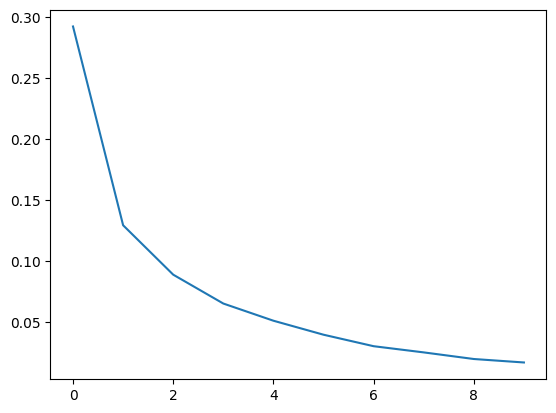

In [ ]:
plt.plot(history.history['loss'])

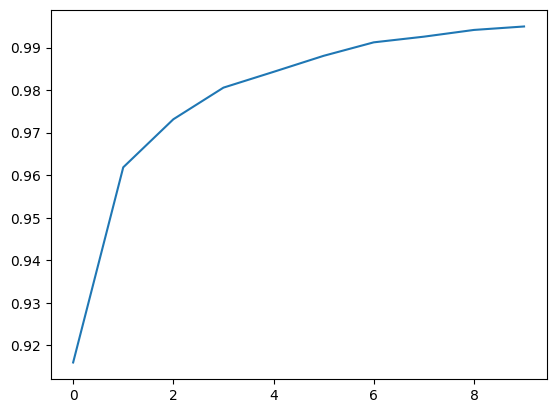

In [ ]:
plt.plot(history.history['accuracy'])


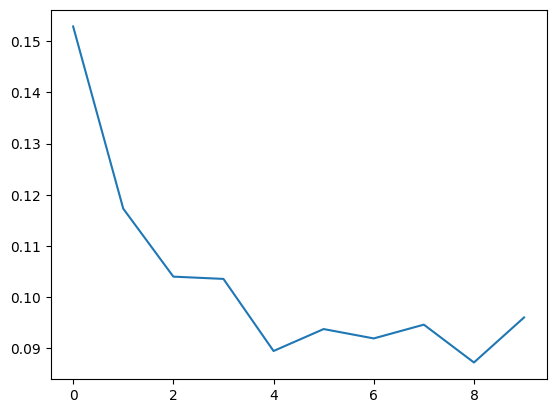

In [18]:
plt.plot(history.history['val_loss'])

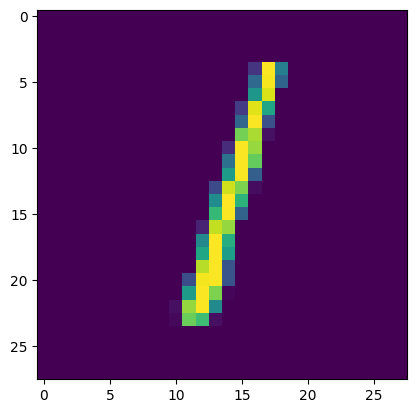

In [24]:
plt.imshow(X_test[2])

In [27]:
model.predict(X_test[2].reshape(1,28,28)).argmax(axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


array([1])